In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
import numpy as np

In [ ]:
df = pd.read_csv('df_top10.csv')

In [ ]:
cols_a_completar = ['Atenciones_Urg', 'Temp_Mediana_Semanal', 'PM25_Mediana_Semanal','PM25_Lag1','PM25_Lag2']

for col in cols_a_completar:
    # Agrupamos por región para que el promedio sea local y no mezcle zonas
    df[col] = df.groupby('RegionNombre')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

#
print("Nulos restantes en el Top 10:")
print(df[cols_a_completar].isnull().sum())

Nulos restantes en el Top 10:
Atenciones_Urg          0
Temp_Mediana_Semanal    0
PM25_Mediana_Semanal    0
PM25_Lag1               0
PM25_Lag2               0
dtype: int64


APLICACIÓN REDES NEURONALES EN UNA REGIÓN

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando RNN para Valparaíso...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step

--- MÉTRICAS RNN FINAL: Valparaíso ---
MAE:  964.34
RMSE: 1300.77
MAPE: 17.88%


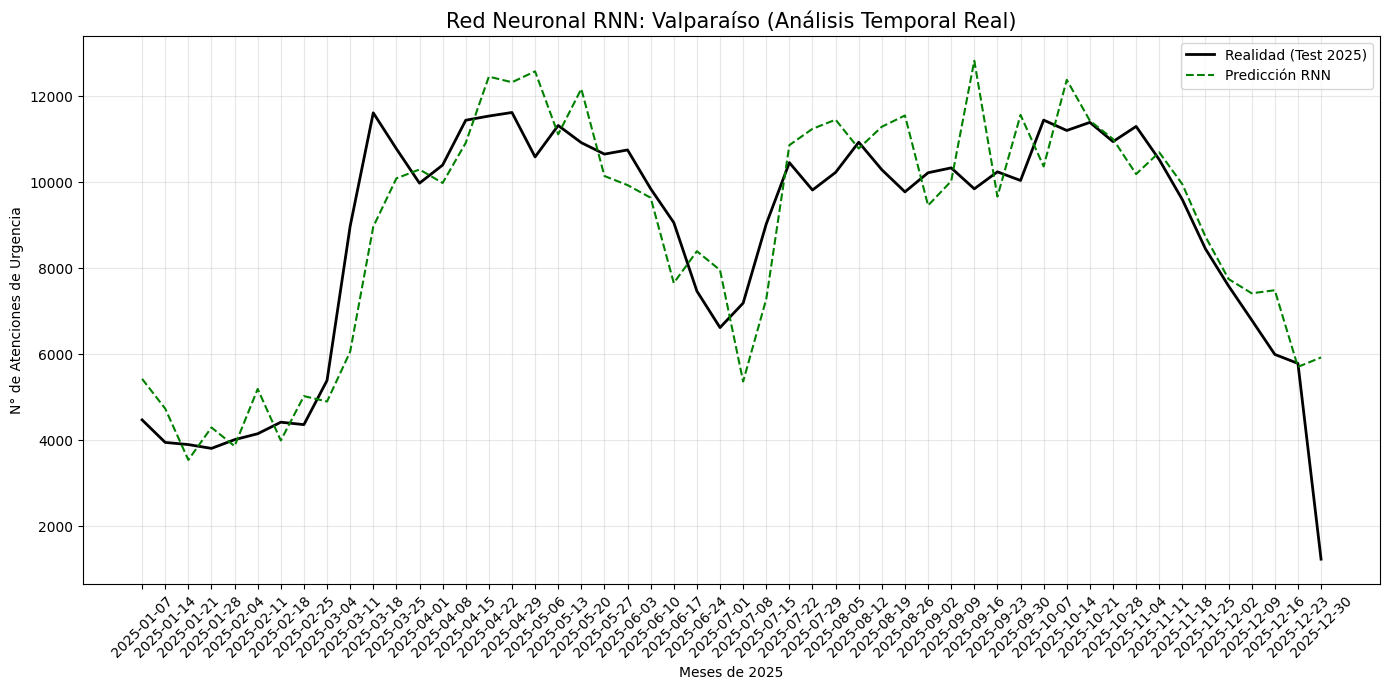

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

# #Realizamos prueba con valpo
region_objetivo = "Valparaíso"
df_reg = df[df['RegionNombre'] == region_objetivo].copy()
df_reg = df_reg.sort_values('Semana')

# Seleccionamos las columnas objetivo y variables exógenas
features = ['Atenciones_Urg', 'PM25_Lag1', 'Temp_Mediana_Semanal']
data = df_reg[features].values

# Normalizamosn con StandardScaler (Media 0, Desviación 1)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

data_scaled_X = scaler_X.fit_transform(data)
data_scaled_y = scaler_y.fit_transform(data[:, 0].reshape(-1, 1))

# creamos las ventanas de tiempo de 4 semanas
def create_sequences(data_X, data_y, window_size=4):
    X, y = [], []
    for i in range(len(data_X) - window_size):
        X.append(data_X[i:i+window_size, :])
        y.append(data_y[i+window_size, 0])
    return np.array(X), np.array(y)

window_size = 4
X, y = create_sequences(data_scaled_X, data_scaled_y, window_size)

# División Train/Test (80% entrenamiento, 20% prueba)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

#Construcción de la red neuronal
model_rnn = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(window_size, len(features))),
    Dense(32, activation='relu'),
    Dense(1)
])

model_rnn.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print(f"Entrenando RNN para {region_objetivo}...")
history = model_rnn.fit(X_train, y_train, epochs=100, batch_size=16,
                        validation_split=0.1, verbose=0)

# Predecimos
y_pred_scaled = model_rnn.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_real = scaler_y.inverse_transform(y_test.reshape(-1, 1))


mae_rnn = mean_absolute_error(y_real, y_pred)
rmse_rnn = np.sqrt(mean_squared_error(y_real, y_pred))
mape_rnn = np.mean(np.abs((y_real - y_pred) / (np.abs(y_real) + 1e-9))) * 100

print(f"\n--- MÉTRICAS RNN FINAL: {region_objetivo} ---")
print(f"MAE:  {mae_rnn:.2f}")
print(f"RMSE: {rmse_rnn:.2f}")
print(f"MAPE: {mape_rnn:.2f}%")

# Gráfico Comparativo

# Como usamos un window_size de 4, la primera predicción corresponde al 5to dato de Test
fechas_test = df_reg['Semana'].iloc[split + window_size:].values


plt.figure(figsize=(14, 7))


plt.plot(fechas_test, y_real, label='Realidad (Test 2025)', color='black', linewidth=2)
plt.plot(fechas_test, y_pred, label=f'Predicción RNN', color='green', linestyle='--')

plt.title(f"Red Neuronal RNN: Valparaíso (Análisis Temporal Real)", fontsize=15)
plt.xlabel("Meses de 2025")
plt.ylabel("N° de Atenciones de Urgencia")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#PRUEBA CON TODAS LAS REGIONES
import warnings

warnings.filterwarnings("ignore") # Para limpiar la salida de TensorFlow


resultados_rnn_final = []
window_size = 4
features = ['Atenciones_Urg', 'PM25_Lag1', 'Temp_Mediana_Semanal']
regiones_top10 = df['RegionNombre'].unique()

print(f"{'Región':<30} | {'MAE':<10} | {'RMSE':<10} | {'MAPE %':<10}")
print("-" * 70)

for reg in regiones_top10:
    try:
        # Filtramos los datos por región
        df_reg = df[df['RegionNombre'] == reg].sort_values('Semana').copy()
        data = df_reg[features].values

        # escalamos
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        data_scaled_X = scaler_X.fit_transform(data)
        data_scaled_y = scaler_y.fit_transform(data[:, 0].reshape(-1, 1))

        X, y = [], []
        for i in range(len(data_scaled_X) - window_size):
            X.append(data_scaled_X[i:i+window_size, :])
            y.append(data_scaled_y[i+window_size, 0])
        X, y = np.array(X), np.array(y)

        # Dividimos train/test 80/20
        split = int(len(X) * 0.8)
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        # Armamos la red
        model = Sequential([
            SimpleRNN(64, activation='tanh', input_shape=(window_size, len(features))),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')

        # entrenamos
        model.fit(X_train, y_train, epochs=80, batch_size=16, verbose=0)

        # 7. Predecir y revertir escala
        y_pred_scaled = model.predict(X_test, verbose=0)
        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        y_real = scaler_y.inverse_transform(y_test.reshape(-1, 1))

        #métricas
        mae_reg = mean_absolute_error(y_real, y_pred)
        rmse_reg = np.sqrt(mean_squared_error(y_real, y_pred))
        mape_reg = np.mean(np.abs((y_real - y_pred) / (np.abs(y_real) + 1e-9))) * 100

        print(f"{reg[:30]:<30} | {mae_reg:>10.2f} | {rmse_reg:>10.2f} | {mape_reg:>10.2f}%")

        resultados_rnn_final.append({
            'Región': reg,
            'MAE_RNN': round(mae_reg, 1),
            'RMSE_RNN': round(rmse_reg, 1),
            'MAPE_RNN %': round(mape_reg, 2)
        })

    except Exception as e:
        print(f"Error en {reg}: {e}")
        resultados_rnn_final.append({'Región': reg, 'MAE_RNN': None})

df_rnn_nacional = pd.DataFrame(resultados_rnn_final)

Región                         | MAE        | RMSE       | MAPE %    
----------------------------------------------------------------------
RM                             |    2914.95 |    4023.93 |      16.26%


Aysén                          |     115.74 |     144.93 |      24.02%
Araucanía                      |     593.37 |     728.51 |      12.47%
Los Lagos                      |     520.37 |     803.23 |      15.21%
Los Ríos                       |     334.71 |     473.39 |      18.48%
Valparaíso                     |     789.55 |    1153.35 |      14.14%
Ñuble                          |     282.66 |     419.10 |      14.90%
Bío-Bío                        |    1136.85 |    1651.07 |      15.27%
O'Higgins                      |     536.06 |     731.52 |      15.09%
Maule                          |     661.78 |    1073.66 |      12.48%
